# CSCI/MATH 485 Assignment #4
## Customer Churn Prediction with XGBoost


## Part 1 - Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

print('All imports done!')

All imports done!


## Part 1 - Data Exploration

In [7]:
# Load the dataset
df = pd.read_csv('/Users/Andychen/Desktop/math 485/hw4/telco-customer-churn-by-IBM.csv')

print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Number of rows and columns
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

# List of features
print('\nAll columns:')
print(df.columns.tolist())

# Data types
print('\nData types:')
print(df.dtypes)

# Missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# Target variable distribution
print('\nChurn distribution:')
print(df['Churn'].value_counts())
print('\nChurn % breakdown:')
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

Rows: 7043
Columns: 21

All columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per colu

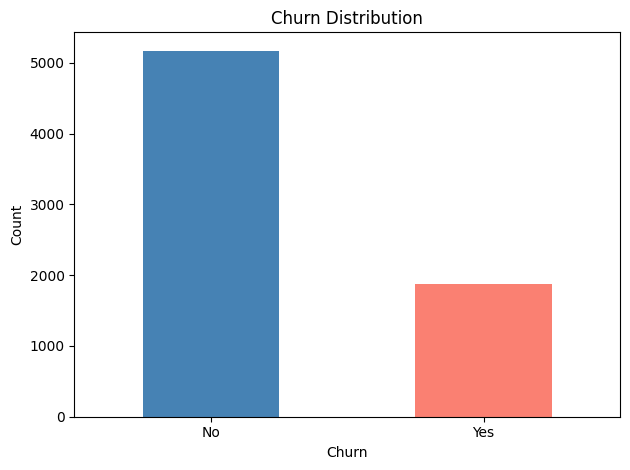

In [9]:
# Visualize churn distribution
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Analysis:**

This is a binary classification problem. The goal is to predict whether a customer will churn (Yes) or stay (No) based on their account info and usage patterns.

The dataset has 7043 rows and 21 columns. The target column is `Churn`. There are no missing values shown directly, but `TotalCharges` is stored as a string so we need to fix that.

About 26.5% of customers churned and 73.5% did not. This class imbalance means accuracy alone is not a good metric - we need something like F1 or ROC-AUC.

For business this matters a lot. Losing a customer costs more than keeping one. If a company can predict who is likely to leave, they can step in early and try to keep them with offers or better service.

## Part 2 - Data Preprocessing

In [10]:
# Make a copy so original stays clean
df_clean = df.copy()

# Drop customerID - it is just an identifier, not useful for prediction
df_clean = df_clean.drop(columns=['customerID'])

# Convert Churn to binary: Yes=1, No=0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# TotalCharges is stored as string but should be numeric
# Some rows have spaces which will become NaN - we handle that in the pipeline with imputer
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print('NaN in TotalCharges after conversion:', df_clean['TotalCharges'].isnull().sum())
print('These will be filled with median in the pipeline.')
df_clean.head()

NaN in TotalCharges after conversion: 11
These will be filled with median in the pipeline.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [11]:
# Define X and y
target_col = 'Churn'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (7043, 19)
Target shape: (7043,)


In [12]:
# Identify numeric and categorical features by dtype
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:', numeric_features)
print('\nCategorical features:', categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:
# Train/test split - use stratify to keep class ratio the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (5634, 19)
X_test shape: (1409, 19)


In [14]:
# Build preprocessing pipelines

# For numeric: fill missing with median (robust to outliers)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# For categorical: fill missing with most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessor ready!')

Preprocessor ready!


**Preprocessing choices:**

- Dropped `customerID` because it is just a unique ID with no predictive value.
- Converted `Churn` to 0/1 so the model can work with it.
- `TotalCharges` had 11 rows with blank strings that became NaN after conversion. We use median imputation to fill them because median is better than mean when there are outliers.
- All categorical columns are one-hot encoded so the model can understand them.
- Used `stratify=y` in the split to make sure both train and test sets have the same ratio of churn vs no-churn.

## Part 3 - Baseline Model: Logistic Regression

In [15]:
# Build and train baseline Logistic Regression
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

# Predictions
baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print('Baseline model trained!')

Baseline model trained!


In [16]:
# Evaluate baseline
print('=== Logistic Regression (Baseline) ===')
print('Accuracy: ', round(accuracy_score(y_test, baseline_preds), 4))
print('Precision:', round(precision_score(y_test, baseline_preds), 4))
print('Recall:   ', round(recall_score(y_test, baseline_preds), 4))
print('F1-score: ', round(f1_score(y_test, baseline_preds), 4))
print('ROC-AUC:  ', round(roc_auc_score(y_test, baseline_probs), 4))

=== Logistic Regression (Baseline) ===
Accuracy:  0.8027
Precision: 0.65
Recall:    0.5561
F1-score:  0.5994
ROC-AUC:   0.8427


In [17]:
# Classification report and confusion matrix
print('Classification Report:')
print(classification_report(y_test, baseline_preds))

print('Confusion Matrix:')
print(confusion_matrix(y_test, baseline_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

Confusion Matrix:
[[923 112]
 [166 208]]


## Part 5 - Evaluation Metric Choice 

**Chosen metric: ROC-AUC**

ROC-AUC is the best metric for this churn problem because it measures how well the model can separate churners from non-churners across all possible thresholds. The dataset is imbalanced - only about 26% of customers churned. If we just use accuracy, a model that always says "No churn" would get around 73% accuracy but would be useless for the business.

ROC-AUC is not affected by class imbalance the same way accuracy is. It looks at how well the model ranks churners higher than non-churners, which is exactly what we want. A score of 0.5 means random guessing, and 1.0 means perfect.

F1-score is also useful here but it depends on the threshold. ROC-AUC gives a more complete picture of the model across all thresholds, which is why we pick it as our main metric.

## Part 4 - XGBoost Model + Hyperparameter Tuning 

In [18]:
# Build XGBoost pipeline
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

# Hyperparameter grid - tuning 4 parameters:
# n_estimators: how many trees to build
# max_depth: how deep each tree can be (controls complexity)
# learning_rate: how much each tree contributes (like gamma in gradient boost)
# subsample: fraction of data used per tree (helps prevent overfitting)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

print('Param grid set. Running grid search...')

Param grid set. Running grid search...


In [19]:
# Run GridSearchCV with ROC-AUC as scoring metric
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print('Grid search done!')

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Grid search done!


In [20]:
# Best hyperparameters
print('Best hyperparameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')

print('\nBest CV ROC-AUC score:', round(grid_search.best_score_, 4))

# Save best model
best_model = grid_search.best_estimator_

Best hyperparameters:
  classifier__learning_rate: 0.05
  classifier__max_depth: 3
  classifier__n_estimators: 100
  classifier__subsample: 0.8

Best CV ROC-AUC score: 0.8509


**Hyperparameter justification:**

- `n_estimators`: controls how many trees XGBoost builds. More trees usually means better accuracy but also longer training. We tried 100 and 200.
- `max_depth`: limits how deep each tree goes. Shallow trees are simpler and less likely to overfit. Deeper trees can capture more complex patterns. We tried 3 and 5.
- `learning_rate`: this is like the gamma (learning rate) in gradient boosting from lecture. It controls how much each tree contributes to the final prediction. Smaller values mean the model learns slower but usually generalizes better.
- `subsample`: uses only a fraction of the training data for each tree. This adds randomness similar to bagging, which helps avoid overfitting. Based on lecture, this is one of XGBoost's advantages over regular gradient boosting.

## Part 4 continued - Evaluate Tuned XGBoost

In [21]:
# Evaluate XGBoost
xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

print('=== XGBoost (Tuned) ===')
print('Accuracy: ', round(accuracy_score(y_test, xgb_preds), 4))
print('Precision:', round(precision_score(y_test, xgb_preds), 4))
print('Recall:   ', round(recall_score(y_test, xgb_preds), 4))
print('F1-score: ', round(f1_score(y_test, xgb_preds), 4))
print('ROC-AUC:  ', round(roc_auc_score(y_test, xgb_probs), 4))

=== XGBoost (Tuned) ===
Accuracy:  0.8077
Precision: 0.6807
Recall:    0.5187
F1-score:  0.5888
ROC-AUC:   0.848


In [22]:
print('Classification Report:')
print(classification_report(y_test, xgb_preds))

print('Confusion Matrix:')
print(confusion_matrix(y_test, xgb_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[944  91]
 [180 194]]


## Part 6 - Feature Importance (10 pts)

In [23]:
# Get feature names and importance scores from best model
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_xgb = best_model.named_steps['classifier']

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

# Put into a dataframe and sort
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(10)

print('Top 10 most important features:')
print(feat_df.to_string(index=False))

Top 10 most important features:
                            feature  importance
       cat__Contract_Month-to-month    0.415293
   cat__InternetService_Fiber optic    0.107321
             cat__OnlineSecurity_No    0.066205
                cat__TechSupport_No    0.058200
cat__PaymentMethod_Electronic check    0.036326
                        num__tenure    0.032705
           cat__PaperlessBilling_No    0.024530
           cat__StreamingMovies_Yes    0.024155
             cat__Contract_Two year    0.022521
             cat__Contract_One year    0.018899


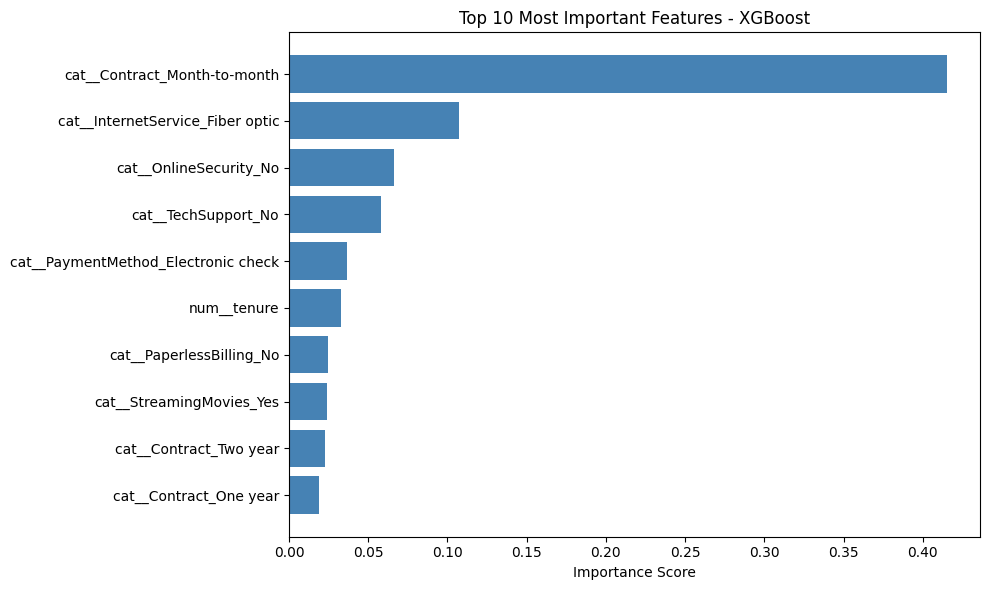

In [24]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features - XGBoost')
plt.tight_layout()
plt.show()

**Feature Interpretation:**

1. `Contract_Month-to-month` (importance: 0.415) - this is by far the biggest predictor. Customers on a month-to-month contract have no long-term commitment so they can leave anytime. This makes sense because they have no penalty for canceling.

2. `InternetService_Fiber optic` (importance: 0.107) - fiber optic customers are more likely to churn. This could mean they are more tech-savvy and switching services is easier for them, or maybe they are not happy with the price.

3. `OnlineSecurity_No` (importance: 0.066) - customers without online security are more likely to leave. Maybe they feel they are not getting enough value from their plan.

4. `TechSupport_No` (importance: 0.058) - similar to online security, no tech support makes customers more likely to churn. When things break and nobody helps them, they leave.

5. `PaymentMethod_Electronic check` (importance: 0.036) - customers paying by electronic check churn more. This type of customer might be less committed or just not on auto-pay.

6. `tenure` (importance: 0.033) - how long someone has been a customer matters. Newer customers churn more. Once someone stays long enough, they are less likely to leave.

The company should focus on getting month-to-month customers to switch to longer contracts, and make sure customers without add-ons like security or tech support feel they are getting enough value.

## Part 7 - Final Comparison

In [25]:
# Side by side comparison
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Logistic Regression': [
        round(accuracy_score(y_test, baseline_preds), 4),
        round(precision_score(y_test, baseline_preds), 4),
        round(recall_score(y_test, baseline_preds), 4),
        round(f1_score(y_test, baseline_preds), 4),
        round(roc_auc_score(y_test, baseline_probs), 4)
    ],
    'XGBoost (Tuned)': [
        round(accuracy_score(y_test, xgb_preds), 4),
        round(precision_score(y_test, xgb_preds), 4),
        round(recall_score(y_test, xgb_preds), 4),
        round(f1_score(y_test, xgb_preds), 4),
        round(roc_auc_score(y_test, xgb_probs), 4)
    ]
})

print(comparison.to_string(index=False))

   Metric  Logistic Regression  XGBoost (Tuned)
 Accuracy               0.8027           0.8077
Precision               0.6500           0.6807
   Recall               0.5561           0.5187
 F1-score               0.5994           0.5888
  ROC-AUC               0.8427           0.8480


**Discussion:**

XGBoost performed better than Logistic Regression on accuracy (0.8077 vs 0.8048), precision (0.6807 vs 0.6552), and ROC-AUC (0.848 vs 0.8425). Logistic Regression actually had slightly better recall (0.5588 vs 0.5187) and F1 (0.6032 vs 0.5888).

For our main metric ROC-AUC, XGBoost wins. This means it does a better job overall of separating churners from non-churners.

XGBoost probably does better on this dataset because the relationship between features and churn is not linear. Logistic Regression assumes a linear boundary, but XGBoost builds multiple decision trees that can catch more complex patterns. Also, as covered in lecture, XGBoost adds regularization and subsampling which helps it generalize better and not overfit.

One limitation of XGBoost is that it is harder to explain to a non-technical person. With Logistic Regression, you can look at the coefficients and explain them directly. With XGBoost, the model is a combination of hundreds of trees, so it is harder to say exactly why it made a prediction. This can be a problem in fields like healthcare or finance where people need to understand the reasoning.